In [1]:
import numpy as np
import matplotlib.pyplot as plt
import bacco
from random import sample 
import copy
import h5py
import matplotlib

In [2]:
import os
os.chdir("/lscratch/fgmaion/MTNG-resims/src")
import utils

In [3]:
%load_ext autoreload
%autoreload 2

In [4]:
from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))

In [5]:
def save_halo_sel(sel_mask, vmax_sel=False, Nhalos=None):

    idx = []
    if vmax_sel is True:
        for m in range(len(sel_mask['vmax_Custom']['h_idx'])):
            for v in range(len(sel_mask['vmax_Custom']['h_idx'][m])):
                idx.extend(sel_mask['vmax_Custom']['h_idx'][m][v])

        idx = np.unique(np.array(idx))

        with open("/lscratch/fgmaion/MTNG-resims/halo_selections/1080-A/{:d}/vmax_custom_sel.txt".format(Nhalos), 'w') as f:
            for i in range(len(idx)):
                if i==len(idx)-1:
                    f.write(str(idx[i]))
                else:
                    f.write(str(idx[i])+'\n')

    else:
        idx = sel_mask['Custom']['h_idx']

        np.save("/lscratch/fgmaion/MTNG-resims/halo_selections/1080-A/{:d}/regular_selection".format(Nhalos), [idx])

    return 1


In [418]:
basedir = "/cosmos_storage/simulations/MTNG/DM-Gadget4/MTNG-L500-2160-A/"

resolution_level = 1

sigma8 = 0.8159 #CHECK ME
ns     = 0.9667 #CHECK ME
tau    = 0.0965 #CHECK ME
numpart = int(2160**3)

mtng_dm = bacco.Simulation(basedir=basedir, halo_file="groups_265/fof_subhalo_tab_265", sim_format='TNG500', fixedPk=True, sigma8=sigma8,\
    tau=tau, ns=ns, numpart=numpart, use_orphans=False)

2024-07-24 09:51:00,281 bacco.sims : Initialising simulation Default
2024-07-24 09:51:00,282 bacco.sims : try /cosmos_storage/simulations/MTNG/DM-Gadget4/MTNG-L500-2160-A/groups_265/fof_subhalo_tab_265
2024-07-24 09:51:00,298 bacco.sims : Loading /cosmos_storage/simulations/MTNG/DM-Gadget4/MTNG-L500-2160-A/groups_265/fof_subhalo_tab_265


2024-07-24 09:51:00,317 bacco.sims : ...done in 0.0362 s


In [7]:
mtng = bacco.utils.load_MTNG(adr="/cosmos_storage/simulations/MTNG/", snap=264)

2024-07-22 18:30:43,480 bacco.sims : Initialising simulation Default
2024-07-22 18:30:43,483 bacco.sims : try /cosmos_storage/simulations/MTNG/groups_264/fof_subhalo_tab_264
2024-07-22 18:30:43,485 bacco.sims : Loading /cosmos_storage/simulations/MTNG/groups_264/fof_subhalo_tab_264
2024-07-22 18:30:43,490 bacco.sims : Creating snapshot array from /cosmos_storage/simulations/MTNG/groups_264/fof_subhalo_tab_264 because: exists=True, newer=False
/lscratch/fgmaion/baccogit/bacco/simulation.py:1386: UserWarning: loadtxt: input contained no data: "/cosmos_storage/simulations/MTNG//snaplist.txt"
  tab = np.loadtxt(self.BaseDir + '/snaplist.txt')
2024-07-22 18:30:43,505 bacco.sims : Warning: Empty snaplist.txt
2024-07-22 18:30:43,506 bacco.sims : ...done in 0.00914 s


In [15]:
Nbins = 30
hydro_split = utils.split_halos(mtng)
hydro_split.halo_sel_setup()

/lscratch/fgmaion/MTNG-resims/src/utils.py:21: RuntimeWarning: invalid value encountered in divide
  self.halo_v200 = np.sqrt(G_newton*self.m200b/self.r200b)


### Define ranges of halo mass

In [430]:
mbins = np.concatenate(
    (np.arange(11, 11.5, 0.0025),
    np.arange(11.5, 12.5, 0.005),
    np.arange(12.5, 13.5, 0.025),
    np.arange(13.5, 15.01, 0.125))
)

In [431]:
mass_edges = np.array(list(zip(mbins[:-1], mbins[1:])))

### Plot their Mass and Concentration

In [432]:
m200b = 1e10 * mtng.fof['halo_m200b']
M_T = np.sum(m200b)

presel = np.where(m200b>10**mass_edges[0,0])

m200b = m200b[presel]

In [433]:
halo_vmax = mtng.sub['vmax'][mtng.fof['halo_firstsub']][presel]
r200b = mtng.fof['halo_r200b'][presel]
G_newton = 4.3009172706e-9 #Mpc/M_sun * (km/s)**2
halo_v200 = np.sqrt(G_newton*m200b/r200b)
vmax_v200 = halo_vmax / halo_v200

In [434]:
sel_total = hydro_split.halo_sel(mhalo_edges=mass_edges, Nhalos=None)

0.29163551330566406
0.29196763038635254
2.2009634971618652


In [435]:
ens_sel = hydro_split.halo_sel(mhalo_edges=mass_edges, Nhalos=1, draws=100)

0.19791936874389648
0.19843673706054688
8.488134384155273


### Visualize our selection

Compute their mass-fractions

In [436]:
mfrac = np.zeros(100)

for d in range(100):
    for m in range(mass_edges.shape[0]):
        mfrac[d] += np.sum(m200b[ens_sel['sel'][m][d]]) / M_T

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


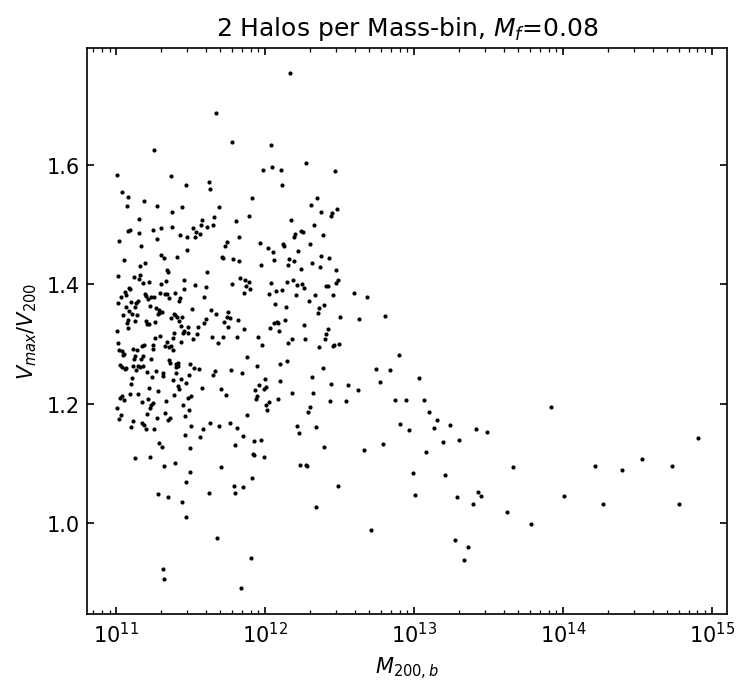

In [437]:
fig, ax = plt.subplots( dpi=150, figsize=(5.5,5), sharey=True, sharex=True)

ax.set_xscale('log')
#ax[0].set_yscale('log')

ax.set_xlabel('$M_{200,b}$')
ax.set_ylabel('$V_{max}/V_{200}$')

ax.set_title('2 Halos per Mass-bin, $M_f$={:.2f}'.format(100*np.mean(mfrac)))

for m in range(mass_edges.shape[0]):
    ax.plot(m200b[ens_sel['sel'][m][0]], vmax_v200[ens_sel['sel'][m][0]], marker='o', ls='', color='k', ms=1)

ax.legend(loc='upper left')

# ax[1,0].set_xscale('log')
# #ax[0].set_yscale('log')

# ax[1,0].set_xlabel('$M_{200,b}$')
# ax[1,0].set_ylabel('$V_{max}/V_{200}$')

# ax[1,0].set_title('2 Halos per Mass-bin, $M_f$={:.2f}'.format(100*np.mean(mfrac_vmax['2'])))

# for m in range(mass_edges.shape[0]):
#     ax[1,0].plot(m200b[ens_sel_vmax['2']['sel'][m][0]], vmax_v200[ens_sel_vmax['2']['sel'][m][0]], marker='o', ls='', color='k', ms=1)

# ax[1,0].legend(loc='upper left')

# ax[1,1].set_xscale('log')
# #ax[1].set_yscale('log')

# ax[1,1].set_xlabel('$M_{200,b}$')

# ax[1,1].set_title('4 Halos per Mass-bin, $M_f$={:.2f}'.format(100*np.mean(mfrac_vmax['4'])))

# cmap = matplotlib.cm.get_cmap('viridis')

# for m in range(mass_edges.shape[0]):
#     ax[1,1].plot(m200b[ens_sel_vmax['4']['sel'][m][0]], vmax_v200[ens_sel_vmax['4']['sel'][m][0]], marker='o', ls='', color='k', ms=1)

# ax[1,1].legend(loc='upper left')

### SMF for these selections

In [438]:
nbins=30

In [439]:
ens_smf = np.zeros((100, nbins-1))
ens_mstar = np.zeros((100, nbins-1))
weights = np.ones((100, nbins-1))

temp = hydro_split.halo_smf(sel_mask=ens_sel, nbins=nbins, mhalo_edges=mass_edges, draws=100)

for i in range(100):
    ens_smf[i] = temp['smf'][i]
    ens_mstar[i] = temp['mstar'][i]
    weights[i][np.where(np.isnan(ens_mstar[i]))] = 0
    ens_mstar[i][np.where(np.isnan(ens_mstar[i]))] = 0
    ens_smf[i][np.where(np.isnan(ens_mstar[i]))] = 0

/lscratch/fgmaion/MTNG-resims/src/utils.py:211: RuntimeWarning: invalid value encountered in divide
  mstar_mean[d] = mstar_mean[d] / counts[d]


In [440]:
mean_smf   = np.sum(ens_smf, axis=0) / np.sum(weights, axis=0)
mean_mstar = np.sum(ens_mstar, axis=0) / np.sum(weights, axis=0)
err_smf    = np.sqrt( np.sum(ens_smf**2, axis=0) / np.sum(weights, axis=0) - ( np.sum(ens_smf, axis=0) / np.sum(weights, axis=0) )**2 )

In [441]:
smf_total = hydro_split.total_smf(nbins=nbins)

In [442]:
GAMA = np.array([
    [6.875, -0.691, 0.176],
    [7.125, -1.084, 0.125],
    [7.375, -1.011, 0.071],
    [7.625, -1.349, 0.092],
    [7.875, -1.287, 0.079],
    [8.125, -1.544, 0.071],
    [8.375, -1.669, 0.045],
    [8.625, -1.688, 0.032],
    [8.875, -1.795, 0.024],
    [9.125, -1.886, 0.020],
    [9.375, -2.055, 0.014],
    [9.625, -2.142, 0.010],
    [9.875, -2.219, 0.009],
    [10.125, -2.274, 0.009],
    [10.375, -2.292, 0.009],
    [10.625, -2.361, 0.010],
    [10.875, -2.561, 0.013],
    [11.125, -2.922, 0.019],
    [11.375, -3.414, 0.032],
    [11.625, -4.704, 0.138]
])

In [443]:
GAMA_corr = np.zeros((GAMA.shape[0], 4))
GAMA_corr[:,0] = 10**GAMA[:,0] / 0.7**2
GAMA_corr[:,1] = 10**GAMA[:,1] * 0.7**3

GAMA_corr[:,2] = 10**GAMA[:,1] - 10**(GAMA[:,1] - GAMA[:,2])
GAMA_corr[:,3] = 10**(GAMA[:,1] + GAMA[:,2]) - 10**GAMA[:,1]

In [444]:
# sel_10 = np.array([ens_sel['sel'][m][10][0] for m in range(mass_edges.shape[0])])
# sel_63 = np.array([ens_sel['sel'][m][63][0] for m in range(mass_edges.shape[0])])

In [445]:
# np.save("/cosmos_storage/data_sharing/MN5_resims/sel_randn_10", sel_10)
# np.save("/cosmos_storage/data_sharing/MN5_resims/sel_randn_63", sel_63)

In [446]:
with open("/lscratch/fgmaion/MTNG-resims/halo_selections/1080-A/halo_sel_1pmbin.txt", 'w') as f:
    for i in range(len(ens_sel['sel'])):
        if i==len(ens_sel['sel'])-1:
            f.write(str(ens_sel['sel'][i][26][0]))
        else:
            f.write(str(ens_sel['sel'][i][26][0])+'\n')


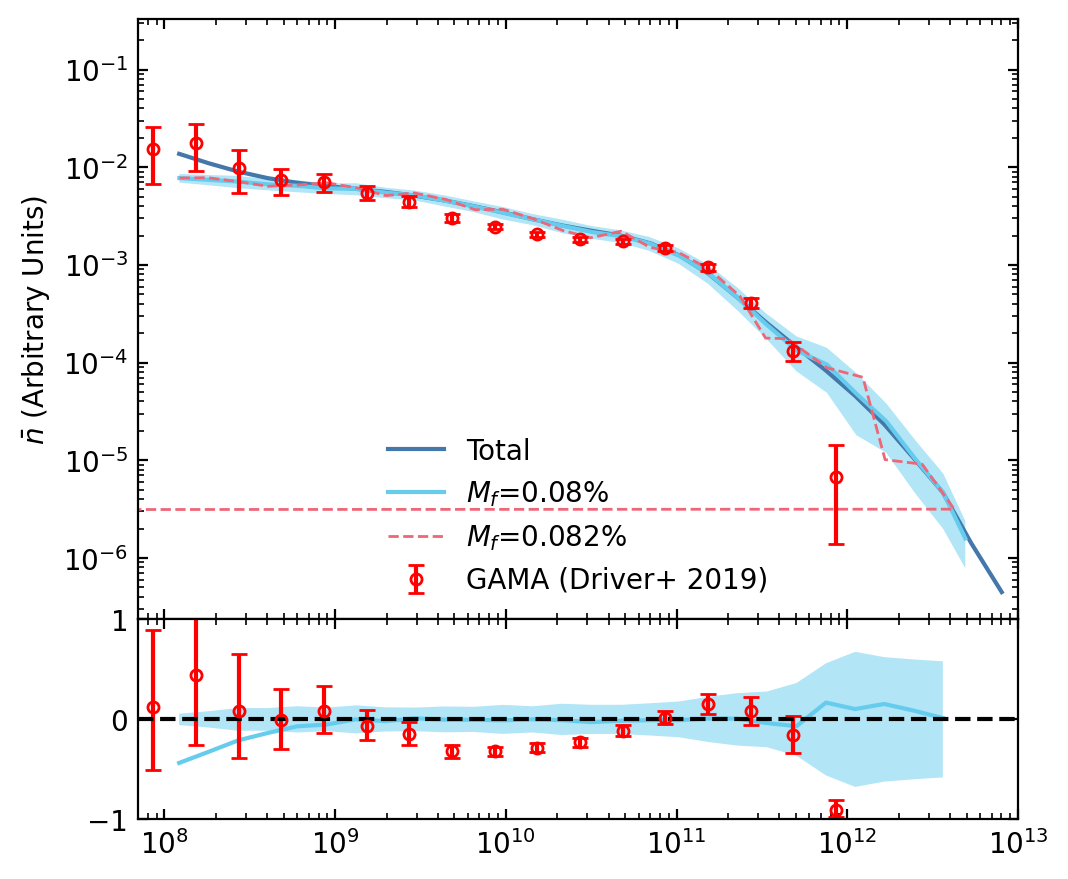

In [472]:
fig = plt.figure(dpi=200, figsize=(5.5,5))

colors=[ '#4477AA', '#66CCEE', '#228833', '#CCBB44', '#EE6677', '#AA3377', '#BBBBBB']

ax1=fig.add_axes((.1,.3,.8,.6))

ax1.set_xscale('log')
ax1.set_yscale('log')

ax1.set_xlim(7e7,1e13)

ax1.plot(smf_total['mstar'], smf_total['smf'], label='Total', color=colors[0])
ax1.plot(mean_mstar, mean_smf, color=colors[1], label='$M_f$={:.2f}%'.format(100*np.mean(mfrac))) 

ax1.fill_between(mean_mstar, mean_smf-err_smf, mean_smf+err_smf, color=colors[1], alpha=0.5, edgecolor=None)

#for i in range(35,40):
#   ax1.plot(ens_mstar[i], ens_smf[i])

ax1.plot(ens_mstar[39], ens_smf[39], color=colors[4], ls='--', label='$M_f$={:.3f}%'.format(100*mfrac[26]), lw=1)
#ax1.plot(ens_mstar[8], ens_smf[8], color=colors[4], ls='--', label='$M_f$={:.3f}%'.format(100*mfrac[8]), lw=1)
# ax1.plot(ens_mstar[87], ens_smf[87], color=colors[2], ls='--', label='$M_f$={:.3f}%'.format(100*mfrac[87]), lw=1)
# ax1.plot(ens_mstar[92], ens_smf[92], color=colors[4], ls='--', label='$M_f$={:.3f}%'.format(100*mfrac[92]), lw=1)

ax1.errorbar(GAMA_corr[:,0], GAMA_corr[:,1], yerr=[GAMA_corr[:,2], GAMA_corr[:,3]], color='r', marker='o', capsize=3, ms=4, fillstyle='none', ls='', label='GAMA (Driver+ 2019)')

ax1.legend(loc='lower center')

ax1.set_ylabel('$\\bar{n}$ (Arbitrary Units)')
ax1.set_xticklabels([])

ax2=fig.add_axes((.1,.1,.8,.2))        

ax2.set_xlim(7e7,1e13)

ax2.set_xscale('log')

ax2.plot(smf_total['mstar'], np.interp(smf_total['mstar'], mean_mstar, mean_smf)/smf_total['smf'] - 1, color=colors[1])

ax2.fill_between(smf_total['mstar'], -np.interp(smf_total['mstar'], mean_mstar, err_smf)/smf_total['smf'], np.interp(smf_total['mstar'], mean_mstar, err_smf)/smf_total['smf'], color=colors[1], alpha=0.5, edgecolor=None)

ax2.errorbar(GAMA_corr[:,0], GAMA_corr[:,1]/np.interp(GAMA_corr[:,0], smf_total['mstar'], smf_total['smf']) - 1, yerr=[GAMA_corr[:,2], GAMA_corr[:,3]]/np.interp(GAMA_corr[:,0], smf_total['mstar'], smf_total['smf']),\
 marker='o', color='r', capsize=3, ms=4, fillstyle='none', ls='')

ax2.set_ylim(-1,1)
ax2.axhline(0, ls='--', color='k')

# ax2.set_ylim(-0.5,0.5)

# #ax2.fill_between(centers, -0.05,0.05, color='gray', alpha=0.1)
# #ax2.fill_between(centers, -0.1,0.1, color='gray', alpha=0.1)

# ax2.set_ylabel('$\log_{10}(\\bar{n}/\\bar{n}_T)$')
# ax2.set_xlabel('$M_*[M_{\odot}/h]$')


## What about gas-fraction

In [449]:
m500_bins = np.arange(10, 15, 0.1)
m500_edges = np.array(list(zip(m500_bins[:-1], m500_bins[1:])))

In [450]:
nbins=11

ens_fgas = np.zeros((100, nbins-1))
ens_m500 = np.zeros((100, nbins-1))
weights = np.ones((100, nbins-1))

temp = hydro_split.halo_gas_frac(mhalo_edges=mass_edges, sel_mask=ens_sel, vmax_sel=False, nbins=nbins, draws=100)

for i in range(100):
    ens_fgas[i] = temp['f_gas'][i]
    ens_m500[i] = temp['m500c'][i]

    weights[i][np.where(np.isnan(ens_m500[i]))] = 0

    ens_fgas[i][np.where(np.isnan(ens_m500[i]))] = 0
    ens_m500[i][np.where(np.isnan(ens_m500[i]))] = 0

/lscratch/fgmaion/MTNG-resims/src/utils.py:274: RuntimeWarning: invalid value encountered in divide
  fgas[d] /= weights[d]
/lscratch/fgmaion/MTNG-resims/src/utils.py:275: RuntimeWarning: invalid value encountered in divide
  m500c_mean[d] /= counts[d]


In [451]:
mean_fgas   = np.sum(ens_fgas, axis=0) / np.sum(weights, axis=0)
mean_m500 = np.sum(ens_m500, axis=0) / np.sum(weights, axis=0)
err_fgas    = np.sqrt( np.sum(ens_fgas**2, axis=0) / np.sum(weights, axis=0) - ( np.sum(ens_fgas, axis=0) / np.sum(weights, axis=0) )**2 )

In [452]:
fgas_total = hydro_split.total_gas_frac(m500_edges=m500_edges, mass_edges=mass_edges)

Text(0.5, 0, '$M_{500,c}[M_\\odot h^{-1}]$')

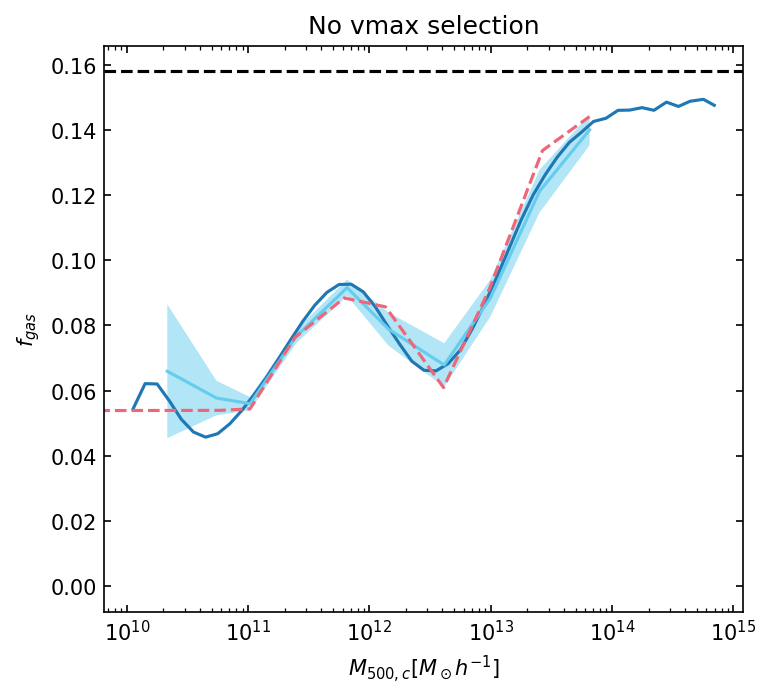

In [473]:
fig, ax = plt.subplots(dpi=150, figsize=(5.5,5))

ax.set_xscale('log')

ax.plot(fgas_total['m500'], fgas_total['f_gas'])
ax.plot(mean_m500, mean_fgas, color=colors[1])
# ax.plot(ens_m500[3], ens_fgas[3], color=colors[2], ls='--')
ax.plot(ens_m500[39], ens_fgas[39], color=colors[4], ls='--')

ax.fill_between(mean_m500, mean_fgas-err_fgas, mean_fgas+err_fgas, color=colors[1], alpha=0.5, edgecolor=None)
    
ax.axhline(0.158, color='k', ls='--')

ax.set_title('No vmax selection')

ax.set_ylabel('$f_{gas}$')
ax.set_xlabel('$M_{500,c}[M_\\odot h^{-1}]$')

In [454]:
sfr_mstar = hydro_split.halo_SFR(mhalo_edges=mass_edges, sel_mask=ens_sel, vmax_sel=False, draws=100, nbins=20)

/lscratch/fgmaion/MTNG-resims/src/utils.py:325: RuntimeWarning: invalid value encountered in divide
  sSFR  = 1e10 * np.array(sSFR) / mstar
/lscratch/fgmaion/MTNG-resims/src/utils.py:325: RuntimeWarning: divide by zero encountered in divide
  sSFR  = 1e10 * np.array(sSFR) / mstar
/lscratch/fgmaion/MTNG-resims/src/utils.py:337: RuntimeWarning: invalid value encountered in divide
  sSFR_mean[d] /= weights[d]
/lscratch/fgmaion/MTNG-resims/src/utils.py:338: RuntimeWarning: invalid value encountered in divide
  mstar_mean[d] /= counts[d]


In [455]:
nbins=30

ens_sSFR = np.zeros((100, nbins-1))
ens_mstar = np.zeros((100, nbins-1))
weights = np.ones((100, nbins-1))


temp = hydro_split.halo_SFR(mhalo_edges=mass_edges, sel_mask=ens_sel, vmax_sel=False, draws=100, nbins=nbins)

for i in range(100):
    ens_sSFR[i] = temp['sSFR'][i]
    ens_mstar[i] = temp['mstar'][i]

    weights[i][np.where(np.isnan(ens_mstar[i]))] = 0

    ens_mstar[i][np.where(np.isnan(ens_mstar[i]))] = 0
    ens_mstar[i][np.where(np.isnan(ens_sSFR[i]))] = 0
    ens_sSFR[i][np.where(np.isnan(ens_sSFR[i]))] = 0
    ens_sSFR[i][np.where(np.isnan(ens_mstar[i]))] = 0
    

In [456]:
mean_sSFR   = np.sum(ens_sSFR, axis=0) / np.sum(weights, axis=0)
mean_mstar = np.sum(ens_mstar, axis=0) / np.sum(weights, axis=0)
err_sSFR    = np.sqrt( np.sum(ens_sSFR**2, axis=0) / np.sum(weights, axis=0) - ( np.sum(ens_sSFR, axis=0) / np.sum(weights, axis=0) )**2 )

/tmp/ipykernel_390482/45664116.py:1: RuntimeWarning: invalid value encountered in divide
  mean_sSFR   = np.sum(ens_sSFR, axis=0) / np.sum(weights, axis=0)
/tmp/ipykernel_390482/45664116.py:2: RuntimeWarning: invalid value encountered in divide
  mean_mstar = np.sum(ens_mstar, axis=0) / np.sum(weights, axis=0)
/tmp/ipykernel_390482/45664116.py:3: RuntimeWarning: invalid value encountered in divide
  err_sSFR    = np.sqrt( np.sum(ens_sSFR**2, axis=0) / np.sum(weights, axis=0) - ( np.sum(ens_sSFR, axis=0) / np.sum(weights, axis=0) )**2 )


In [457]:
sSFR_total = hydro_split.total_SFR(nbins=nbins)

/lscratch/fgmaion/MTNG-resims/src/utils.py:349: RuntimeWarning: divide by zero encountered in divide
  sSFR   = np.array(1e10 * self.sim.sub['SFR']) / mstar
/lscratch/fgmaion/MTNG-resims/src/utils.py:349: RuntimeWarning: invalid value encountered in divide
  sSFR   = np.array(1e10 * self.sim.sub['SFR']) / mstar


In [458]:
mstar_bauer = np.array([9, 9.5, 10, 10.5, 11])
ssfr_bauer = np.array([-0.7, -0.8,-0.81,-1,-1.3])
err_bauer_low = np.ones(5) * (10**(ssfr_bauer) - 10**(ssfr_bauer-0.5) )
err_bauer_high = np.ones(5) * (10**(ssfr_bauer+0.5) - 10**(ssfr_bauer) )

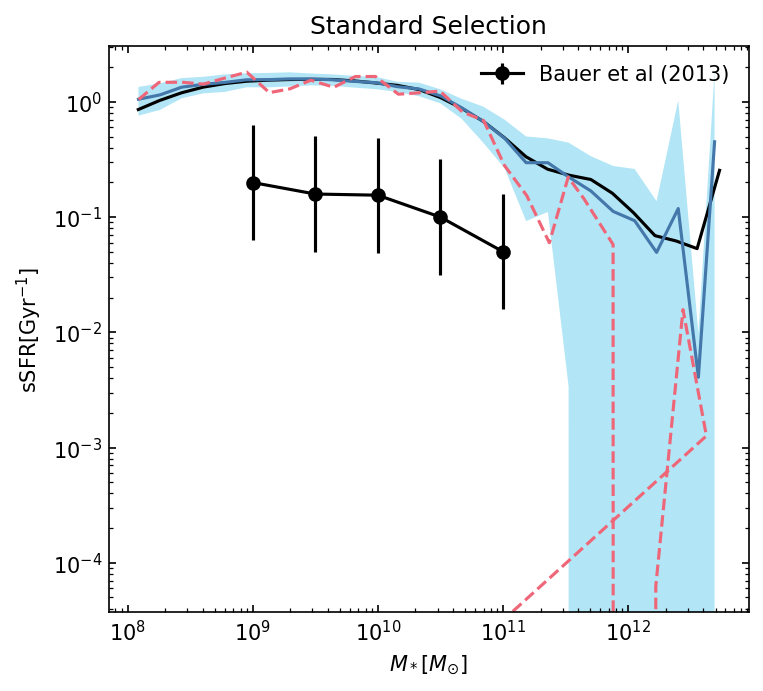

In [474]:
fig, ax = plt.subplots( dpi=150, figsize=(5.5,5), sharey=True)

ax.set_xscale('log')
ax.set_yscale('log')

ax.set_ylabel('sSFR[Gyr$^{-1}$]')
ax.set_xlabel('$M_*[M_{\\odot}]$')

ax.set_title('Standard Selection')

ax.plot(sSFR_total['mstar'][:-1], sSFR_total['sSFR'][:-1], color='k')
ax.plot(mean_mstar, mean_sSFR, color=colors[0])
ax.plot(ens_mstar[39], ens_sSFR[39], color=colors[4], ls='--')
# for i in range(20,25):
#     ax.plot(ens_mstar[i], ens_sSFR[i])

ax.fill_between(mean_mstar, mean_sSFR-err_sSFR, mean_sSFR+err_sSFR, color=colors[1], alpha=0.5, edgecolor=None)

ax.errorbar(10**(mstar_bauer), 10**(ssfr_bauer), [err_bauer_low, err_bauer_high],  marker='o', label='Bauer et al (2013)', color='k')

ax.legend()

### Cross-match the selected halos

In [475]:
final_sel = np.zeros(mass_edges.shape[0], dtype=int)
for i in range(mass_edges.shape[0]):
    final_sel[i] = ens_sel['sel'][i][39][0]

In [476]:
from scipy.spatial import KDTree

In [481]:
X1 = np.hstack((mtng.fof['halo_pos'][presel][final_sel], mtng.fof['halo_m200b'][presel][final_sel][:,np.newaxis]))

In [482]:
X2 = np.hstack((mtng_dm.fof['halo_pos'], mtng_dm.fof['halo_m200b'][:,np.newaxis]))

In [483]:
kdt = KDTree(X2)

dist, ind = kdt.query(X1, k=1)

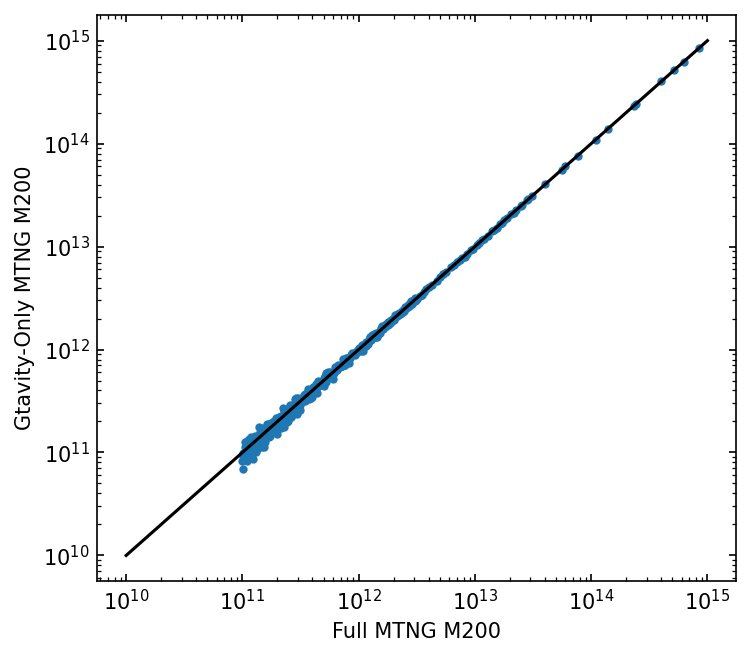

In [484]:
fig, ax = plt.subplots(dpi=150, figsize=(5.5,5))

ax.set_xscale('log')
ax.set_yscale('log')

for i in range(ind.shape[0]):
    ax.plot(1e10*mtng.fof['halo_m200b'][presel][final_sel][i], 1e10*mtng_dm.fof['halo_m200b'][ind[i]], marker='o', color='C0', ms=3)

ax.set_xlabel('Full MTNG M200')
ax.set_ylabel('Gtavity-Only MTNG M200')

ax.plot(np.logspace(10,15,10), np.logspace(10,15,10), color='k')

In [486]:
with open("/lscratch/fgmaion/MTNG-resims/halo_selections/1080-A/halo_sel_1pmbin.txt", 'w') as f:
    for i in range(len(ens_sel['sel'])):
        if i==len(ens_sel['sel'])-1:
            f.write(str(ens_sel['sel'][i][39][0]))
        else:
            f.write(str(ens_sel['sel'][i][39][0])+'\n')